In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

path = "/content/drive/MyDrive/Procurement/Procurement_KPI_Analysis_Dataset.csv"
df = pd.read_csv(path)

In [3]:
import pandas as pd

df = pd.read_csv(path)
display(df.isnull().sum())

,0
PO_ID,0
Supplier,0
Order_Date,0
Delivery_Date,87
Item_Category,0
Order_Status,0
Quantity,0
Unit_Price,0
Negotiated_Price,0
Defective_Units,136


In [4]:
display(df.dtypes)

,0
PO_ID,object
Supplier,object
Order_Date,object
Delivery_Date,object
Item_Category,object
Order_Status,object
Quantity,int64
Unit_Price,float64
Negotiated_Price,float64
Defective_Units,float64


In [5]:
model_df = df.copy()
display(model_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Quantity,777.0,1094.660232,647.844551,51.00,615.00,1075.00,1548.00,5000.00
Unit_Price,777.0,58.283822,28.101315,10.84,33.29,58.95,83.13,109.17
Negotiated_Price,777.0,53.660721,26.094930,9.27,30.46,53.80,76.55,107.39
Defective_Units,641.0,74.803432,69.187870,0.00,26.00,49.00,100.00,321.00


**Step 1 - Calculating the Lead time**

In [6]:
lead_time_df = df[
    (df['Order_Status'] == 'Delivered') &
    (df['Delivery_Date'].notnull())
].copy()

lead_time_df['Order_Date'] = pd.to_datetime(lead_time_df['Order_Date'])
lead_time_df['Delivery_Date'] = pd.to_datetime(lead_time_df['Delivery_Date'])

lead_time_df['Lead_Time'] = (lead_time_df['Delivery_Date'] - lead_time_df['Order_Date']).dt.days

In [7]:
lead_time_summary = lead_time_df.groupby('Supplier')['Lead_Time'].agg(['mean', 'median', 'std', 'min', 'max'])
display(lead_time_summary)

,mean,median,std,min,max
Supplier,,,,,
Alpha_Inc,10.539326,11.0,5.833010,-5,20
Beta_Supplies,11.230000,12.0,5.981208,1,20
Delta_Logistics,10.271845,10.0,6.091129,1,20
Epsilon_Group,10.485981,11.0,5.610577,1,20
Gamma_Co,9.903226,10.0,5.379236,1,20


**Step 2 - Calculating the integral KPIs**

**Supplier Negligence Score (SNS)**

In [8]:
negligence_count = df[df['Order_Status'] == 'Delivered'] \
                     .groupby('Supplier')['Delivery_Date'] \
                     .apply(lambda x: x.isnull().sum())

total_delivered = df[df['Order_Status'] == 'Delivered'] \
                    .groupby('Supplier')['Delivery_Date'] \
                    .size()

negligence_rate = (negligence_count / total_delivered).round(3)  # 3 decimal places

display(negligence_rate)
display(negligence_count)

,Delivery_Date
Supplier,
Alpha_Inc,0.168
Beta_Supplies,0.091
Delta_Logistics,0.142
Epsilon_Group,0.108
Gamma_Co,0.097


,Delivery_Date
Supplier,
Alpha_Inc,18
Beta_Supplies,10
Delta_Logistics,17
Epsilon_Group,13
Gamma_Co,10


**Supplier Cancellation Rate (SCR)**

In [9]:
cancelled = df[df['Order_Status'] == 'Cancelled'].groupby('Supplier').size()
total_orders = df.groupby('Supplier').size()

supplier_cancellation_rate = cancelled / total_orders
display(supplier_cancellation_rate)

,0
Supplier,
Alpha_Inc,0.092199
Beta_Supplies,0.089744
Delta_Logistics,0.093567
Epsilon_Group,0.084337
Gamma_Co,0.041958


**Supplier Defect Rate (SDR)**

In [10]:
defects = df[df['Order_Status'] == 'Delivered'].groupby('Supplier')['Defective_Units'].sum()
delivered_qty = df[df['Order_Status'] == 'Delivered'].groupby('Supplier')['Quantity'].sum()

supplier_defect_rate = defects / delivered_qty
display(supplier_defect_rate)

,0
Supplier,
Alpha_Inc,0.018153
Beta_Supplies,0.074192
Delta_Logistics,0.106421
Epsilon_Group,0.025771
Gamma_Co,0.044518


**Supplier Cost Efficiency Score (SCES)**

In [11]:
df['Price_Difference'] = df['Unit_Price'] - df['Negotiated_Price']

cost_efficiency = df.groupby('Supplier')['Price_Difference'].mean()
display(cost_efficiency)

,Price_Difference
Supplier,
Alpha_Inc,4.738369
Beta_Supplies,4.671538
Delta_Logistics,4.337719
Epsilon_Group,4.757229
Gamma_Co,4.642168


**Supplier Compliance Score (SCS)**

In [12]:
valid_compliance_df = df[
    (df['Order_Status'] != 'Cancelled') &
    (df['Delivery_Date'].notnull() | (df['Order_Status'] == 'Pending') | (df['Order_Status'] == 'Partially Delivered'))
].copy()
display(valid_compliance_df.head())

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Price_Difference
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,1.98
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes,3.25
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes,4.33
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No,3.54
5,PO-00006,Epsilon_Group,2022-08-17,2022-08-29,MRO,Delivered,1145,69.21,63.57,39.0,Yes,5.64


In [13]:
valid_compliance_df['Compliance_Flag'] = valid_compliance_df['Compliance'].map({'Yes': 1, 'No': 0})
display(valid_compliance_df.head())

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Price_Difference,Compliance_Flag
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,1.98,1
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes,3.25,1
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes,4.33,1
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No,3.54,0
5,PO-00006,Epsilon_Group,2022-08-17,2022-08-29,MRO,Delivered,1145,69.21,63.57,39.0,Yes,5.64,1


In [14]:
supplier_compliance_score = valid_compliance_df.groupby('Supplier')['Compliance_Flag'].mean()
display(supplier_compliance_score)

,Compliance_Flag
Supplier,
Alpha_Inc,0.936364
Beta_Supplies,0.757576
Delta_Logistics,0.608696
Epsilon_Group,0.978417
Gamma_Co,0.842520


**Step 3 - Normalizing the KPIs**

In [15]:
import pandas as pd

def min_max_normalize(series):
    """Return 0–1 normalized series. If constant, return 1.0 for all."""
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series(1.0, index=series.index)
    return (series - min_val) / (max_val - min_val)

In [16]:
import pandas as pd

# Consolidate all relevant KPIs into a single DataFrame
supplier_kpis = pd.DataFrame({
    'Lead_Time': lead_time_summary['mean'], # Mean Lead Time (Bad when high)
    'Negligence_Score': negligence_rate,        # Negligence Count (Bad when high)
    'Cancellation_Rate': supplier_cancellation_rate, # Cancellation Rate (Bad when high)
    'Defect_Rate': supplier_defect_rate,   # Defect Rate (Bad when high)
    'Cost_Efficiency': cost_efficiency,    # Mean Price Difference (Good when high)
    'Compliance_Score': supplier_compliance_score # Compliance Score (Good when high)
})

display(supplier_kpis)

,Lead_Time,Negligence_Score,Cancellation_Rate,Defect_Rate,Cost_Efficiency,Compliance_Score
Supplier,,,,,,
Alpha_Inc,10.539326,0.168,0.092199,0.018153,4.738369,0.936364
Beta_Supplies,11.230000,0.091,0.089744,0.074192,4.671538,0.757576
Delta_Logistics,10.271845,0.142,0.093567,0.106421,4.337719,0.608696
Epsilon_Group,10.485981,0.108,0.084337,0.025771,4.757229,0.978417
Gamma_Co,9.903226,0.097,0.041958,0.044518,4.642168,0.842520


In [17]:
# Make a working copy
kpis = supplier_kpis.copy()

# --- BAD WHEN HIGH: Negligence, Cancellation, Defect, Lead Time ---
# raw 0–1
kpis['Lead_Time_raw_norm']   = min_max_normalize(kpis['Lead_Time'])
kpis['Negligence_raw_norm']  = min_max_normalize(kpis['Negligence_Score'])
kpis['Cancellation_raw_norm'] = min_max_normalize(kpis['Cancellation_Rate'])
kpis['Defect_raw_norm']      = min_max_normalize(kpis['Defect_Rate'])

# invert → higher is better
kpis['Lead_Time_norm']    = 1 - kpis['Lead_Time_raw_norm']
kpis['Negligence_norm']   = 1 - kpis['Negligence_raw_norm']
kpis['Cancellation_norm'] = 1 - kpis['Cancellation_raw_norm']
kpis['Defect_norm']       = 1 - kpis['Defect_raw_norm']

# --- GOOD WHEN HIGH: Cost efficiency, Compliance ---
kpis['CostEff_norm']      = min_max_normalize(kpis['Cost_Efficiency'])
kpis['Compliance_norm']   = min_max_normalize(kpis['Compliance_Score'])

display(kpis)

,Lead_Time,Negligence_Score,Cancellation_Rate,Defect_Rate,Cost_Efficiency,Compliance_Score,Lead_Time_raw_norm,Negligence_raw_norm,Cancellation_raw_norm,Defect_raw_norm,Lead_Time_norm,Negligence_norm,Cancellation_norm,Defect_norm,CostEff_norm,Compliance_norm
Supplier,,,,,,,,,,,,,,,,
Alpha_Inc,10.539326,0.168,0.092199,0.018153,4.738369,0.936364,0.479434,1.000000,0.973480,0.000000,0.520566,0.000000,0.026520,1.000000,0.955042,0.886256
Beta_Supplies,11.230000,0.091,0.089744,0.074192,4.671538,0.757576,1.000000,0.000000,0.925911,0.634881,0.000000,1.000000,0.074089,0.365119,0.795737,0.402682
Delta_Logistics,10.271845,0.142,0.093567,0.106421,4.337719,0.608696,0.277831,0.662338,1.000000,1.000000,0.722169,0.337662,0.000000,0.000000,0.000000,0.000000
Epsilon_Group,10.485981,0.108,0.084337,0.025771,4.757229,0.978417,0.439227,0.220779,0.821158,0.086308,0.560773,0.779221,0.178842,0.913692,1.000000,1.000000
Gamma_Co,9.903226,0.097,0.041958,0.044518,4.642168,0.842520,0.000000,0.077922,0.000000,0.298702,1.000000,0.922078,1.000000,0.701298,0.725725,0.632433


**Step 4 - Calculating Supplier Score**
[SPS=(0.25 X SCS)+(0.30 X SQS)+(0.25 X SCES)+(0.10 X SNS)+(0.10 X SCR)]
 *All KPIs used are normalized values

In [18]:
kpis['SPS'] = (
    0.25 * kpis['Compliance_norm'] +
    0.30 * kpis['Defect_norm'] +
    0.25 * kpis['CostEff_norm'] +
    0.10 * kpis['Negligence_norm'] +
    0.10 * kpis['Cancellation_norm']
)
display(kpis)

,Lead_Time,Negligence_Score,Cancellation_Rate,Defect_Rate,Cost_Efficiency,Compliance_Score,Lead_Time_raw_norm,Negligence_raw_norm,Cancellation_raw_norm,Defect_raw_norm,Lead_Time_norm,Negligence_norm,Cancellation_norm,Defect_norm,CostEff_norm,Compliance_norm,SPS
Supplier,,,,,,,,,,,,,,,,,
Alpha_Inc,10.539326,0.168,0.092199,0.018153,4.738369,0.936364,0.479434,1.000000,0.973480,0.000000,0.520566,0.000000,0.026520,1.000000,0.955042,0.886256,0.762977
Beta_Supplies,11.230000,0.091,0.089744,0.074192,4.671538,0.757576,1.000000,0.000000,0.925911,0.634881,0.000000,1.000000,0.074089,0.365119,0.795737,0.402682,0.516549
Delta_Logistics,10.271845,0.142,0.093567,0.106421,4.337719,0.608696,0.277831,0.662338,1.000000,1.000000,0.722169,0.337662,0.000000,0.000000,0.000000,0.000000,0.033766
Epsilon_Group,10.485981,0.108,0.084337,0.025771,4.757229,0.978417,0.439227,0.220779,0.821158,0.086308,0.560773,0.779221,0.178842,0.913692,1.000000,1.000000,0.869914
Gamma_Co,9.903226,0.097,0.041958,0.044518,4.642168,0.842520,0.000000,0.077922,0.000000,0.298702,1.000000,0.922078,1.000000,0.701298,0.725725,0.632433,0.742137


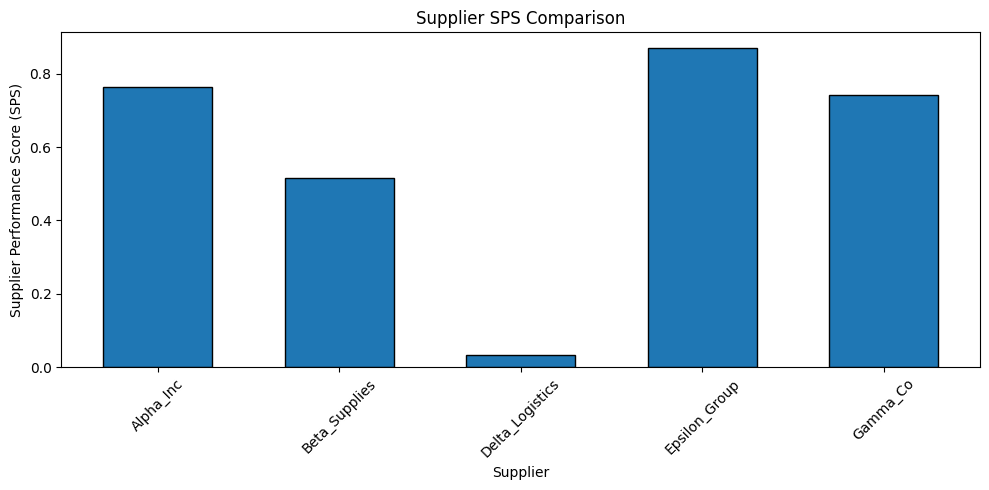

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(supplier_scores['Supplier'], supplier_scores['SPS'], edgecolor='black', width=0.6)
plt.xlabel('Supplier')
plt.ylabel('Supplier Performance Score (SPS)')
plt.title('Supplier SPS Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

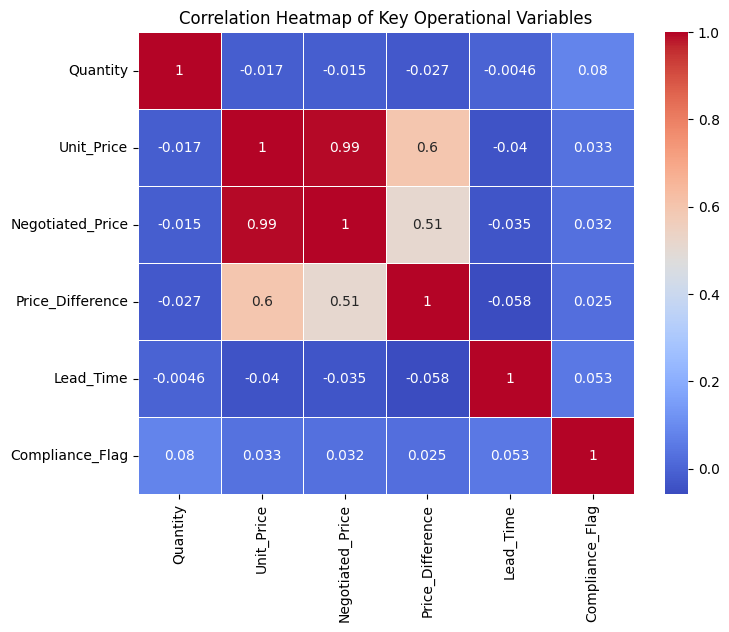

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns from model_df for correlation
correlation_data = model_df[['Quantity', 'Unit_Price', 'Negotiated_Price', 'Price_Difference', 'Lead_Time', 'Compliance_Flag']]

plt.figure(figsize=(8,6))
sns.heatmap(correlation_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Key Operational Variables')
plt.show()

**Step 5 - Identifying Unique Product Categories and Defining Dimensions of Criticality**

In [21]:
display(df['Item_Category'].unique())

array(['Office Supplies', 'MRO', 'Packaging', 'Raw Materials',
       'Electronics'], dtype=object)

In [22]:
pcs_mapping = {
    'Raw Materials': 5,
    'Electronics': 4,
    'MRO': 3,
    'Packaging': 2,
    'Office Supplies': 1
}

df['PCS'] = df['Item_Category'].map(pcs_mapping)
display(df.head())

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Price_Difference,PCS
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes,2.32,1
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,1.98,1
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes,3.25,3
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes,4.33,2
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No,3.54,5


**Step 6 - Calculating the Product Recommendation Score (PRS)**
[PRS = SRPS X PCS]



In [23]:
# Keep only Supplier and SPS columns
supplier_scores = kpis[['SPS']].reset_index().rename(columns={'index': 'Supplier'})

# Merge SPS into the main df
df_with_sps = df.merge(supplier_scores, on='Supplier', how='left')
display(df_with_sps.head())

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Price_Difference,PCS,SPS
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes,2.32,1,0.762977
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,1.98,1,0.033766
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes,3.25,3,0.742137
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes,4.33,2,0.516549
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No,3.54,5,0.033766


In [24]:
df_with_sps['PRS'] = df_with_sps['SPS'] * df_with_sps['PCS']
display(df_with_sps.head())

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Price_Difference,PCS,SPS,PRS
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes,2.32,1,0.762977,0.762977
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,1.98,1,0.033766,0.033766
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes,3.25,3,0.742137,2.226410
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes,4.33,2,0.516549,1.033098
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No,3.54,5,0.033766,0.168831


In [25]:
display(df_with_sps[['Supplier', 'Item_Category', 'PCS', 'SPS', 'PRS']].head(10))

,Supplier,Item_Category,PCS,SPS,PRS
0,Alpha_Inc,Office Supplies,1,0.762977,0.762977
1,Delta_Logistics,Office Supplies,1,0.033766,0.033766
2,Gamma_Co,MRO,3,0.742137,2.226410
3,Beta_Supplies,Packaging,2,0.516549,1.033098
4,Delta_Logistics,Raw Materials,5,0.033766,0.168831
5,Epsilon_Group,MRO,3,0.869914,2.609742
6,Gamma_Co,MRO,3,0.742137,2.226410
7,Alpha_Inc,MRO,3,0.762977,2.288930
8,Gamma_Co,Raw Materials,5,0.742137,3.710684
9,Gamma_Co,Raw Materials,5,0.742137,3.710684


**Step 7 - Supplier Vs PRS Matrix**

In [26]:
prs_matrix = (
    df_with_sps
    .groupby(['Supplier', 'Item_Category'])['PRS']
    .mean()
    .reset_index()
)

display(prs_matrix)

,Supplier,Item_Category,PRS
0,Alpha_Inc,Electronics,3.051906
1,Alpha_Inc,MRO,2.288930
2,Alpha_Inc,Office Supplies,0.762977
3,Alpha_Inc,Packaging,1.525953
4,Alpha_Inc,Raw Materials,3.814883
5,Beta_Supplies,Electronics,2.066196
6,Beta_Supplies,MRO,1.549647
7,Beta_Supplies,Office Supplies,0.516549
8,Beta_Supplies,Packaging,1.033098
9,Beta_Supplies,Raw Materials,2.582745


In [27]:
prs_pivot = prs_matrix.pivot(index='Supplier', columns='Item_Category', values='PRS')
display(prs_pivot)

Item_Category,Electronics,MRO,Office Supplies,Packaging,Raw Materials
Supplier,,,,,
Alpha_Inc,3.051906,2.288930,0.762977,1.525953,3.814883
Beta_Supplies,2.066196,1.549647,0.516549,1.033098,2.582745
Delta_Logistics,0.135065,0.101299,0.033766,0.067532,0.168831
Epsilon_Group,3.479656,2.609742,0.869914,1.739828,4.349570
Gamma_Co,2.968547,2.226410,0.742137,1.484273,3.710684


**PREDICTIVE ANALYTICS - PREDICT COMPLIANCE USING LOGISTIC REGRESSION**

### Data Preparation for Classification Model

To ensure all necessary features and the target variable are available in a single DataFrame for the model, I'll merge the `Lead_Time` from `lead_time_df` and `Compliance_Flag` from `valid_compliance_df` into a new DataFrame called `model_df`. Rows with missing `Compliance_Flag` or `Lead_Time` will be dropped, as these indicate orders that do not fit the criteria for compliance calculation or delivered lead time.

Additionally, rows that still having missing values in the numeric features were dropped to prevent issues during model training.

In [28]:
import pandas as pd
model_df = df.copy()

# Merge Lead_Time from lead_time_df
# Select only relevant columns for merge: 'PO_ID' and 'Lead_Time'
lead_time_subset = lead_time_df[['PO_ID', 'Lead_Time']]
model_df = pd.merge(model_df, lead_time_subset, on='PO_ID', how='left')

# Merge Compliance_Flag from valid_compliance_df
# Select only relevant columns for merge: 'PO_ID' and 'Compliance_Flag'
compliance_subset = valid_compliance_df[['PO_ID', 'Compliance_Flag']]
model_df = pd.merge(model_df, compliance_subset, on='PO_ID', how='left')

# Define the numeric columns that will be used as features
numeric_cols_for_X1 = ['Quantity', 'Unit_Price', 'Negotiated_Price', 'Price_Difference', 'Lead_Time']

# Drop rows where 'Compliance_Flag', 'Lead_Time', or any other numeric feature is NaN
# This ensures the target and critical features are complete for model training.
model_df.dropna(subset=['Compliance_Flag', 'Lead_Time'] + numeric_cols_for_X1, inplace=True)

# Convert Compliance_Flag to int for the target variable (0 or 1)
model_df['Compliance_Flag'] = model_df['Compliance_Flag'].astype(int)

print(f"Shape of the prepared dataframe for modeling: {model_df.shape}")
display(model_df.head())
display(model_df.info())

Shape of the prepared dataframe for modeling: (492, 15)


,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Price_Difference,PCS,Lead_Time,Compliance_Flag
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,1.98,1,10.0,1
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes,3.25,3,20.0,1
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes,4.33,2,19.0,1
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No,3.54,5,12.0,0
5,PO-00006,Epsilon_Group,2022-08-17,2022-08-29,MRO,Delivered,1145,69.21,63.57,39.0,Yes,5.64,3,12.0,1


<class 'pandas.core.frame.DataFrame'>
Index: 492 entries, 1 to 776
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             492 non-null    object 
 1   Supplier          492 non-null    object 
 2   Order_Date        492 non-null    object 
 3   Delivery_Date     492 non-null    object 
 4   Item_Category     492 non-null    object 
 5   Order_Status      492 non-null    object 
 6   Quantity          492 non-null    int64  
 7   Unit_Price        492 non-null    float64
 8   Negotiated_Price  492 non-null    float64
 9   Defective_Units   402 non-null    float64
 10  Compliance        492 non-null    object 
 11  Price_Difference  492 non-null    float64
 12  PCS               492 non-null    int64  
 13  Lead_Time         492 non-null    float64
 14  Compliance_Flag   492 non-null    int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 61.5+ KB


None

### Classification Model Training and Evaluation

Now that the data is prepared in `model_df`, Logistic Regression classifier is used to predict the `Compliance_Flag`. The model will use one-hot encoding for categorical features (`Supplier`, `Item_Category`) and pass through numeric features (`Quantity`, `Unit_Price`, `Negotiated_Price`, `Price_Difference`, `Lead_Time`). After training, the model's performance will be evaluated using accuracy, confusion matrix, and a classification report.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Classification Target
y1 = model_df['Compliance_Flag']

# 2. Features
X1 = model_df[['Quantity', 'Unit_Price', 'Negotiated_Price', 'Price_Difference',
             'Lead_Time', 'Supplier', 'Item_Category']]

# 3. Preprocessing (encode categorical)
categorical_cols = ['Supplier', 'Item_Category']
numeric_cols = ['Quantity', 'Unit_Price', 'Negotiated_Price', 'Price_Difference', 'Lead_Time']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

# 4. Build model pipeline
clf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000)) # Increased max_iter to address convergence warning
])

# 5. Train/test split
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# 6. Train
clf_model.fit(X1_train, y1_train)

# 7. Predict
y1_pred = clf_model.predict(X1_test)

# 8. Evaluate
print("Accuracy:", accuracy_score(y1_test, y1_pred))
print("Confusion Matrix:\n", confusion_matrix(y1_test, y1_pred))
print("Classification Report:\n", classification_report(y1_test, y1_pred))

Accuracy: 0.8585858585858586
Confusion Matrix:
 [[ 1 14]
 [ 0 84]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.07      0.12        15
           1       0.86      1.00      0.92        84

    accuracy                           0.86        99
   macro avg       0.93      0.53      0.52        99
weighted avg       0.88      0.86      0.80        99



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


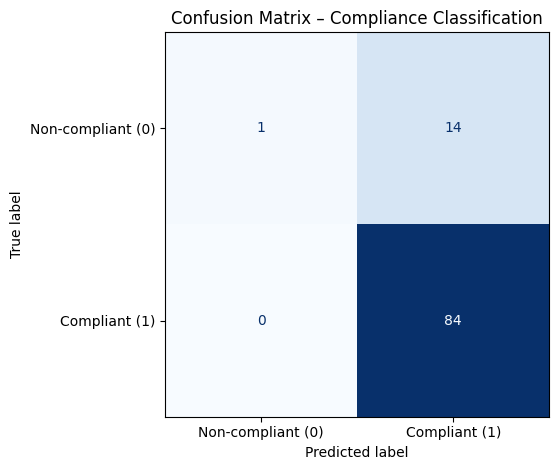

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming:
# y1_test = true labels (0 = non-compliant, 1 = compliant)
# y1_pred = model predictions

disp = ConfusionMatrixDisplay.from_predictions(
    y1_test,
    y1_pred,
    display_labels=["Non-compliant (0)", "Compliant (1)"],
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix – Compliance Classification")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

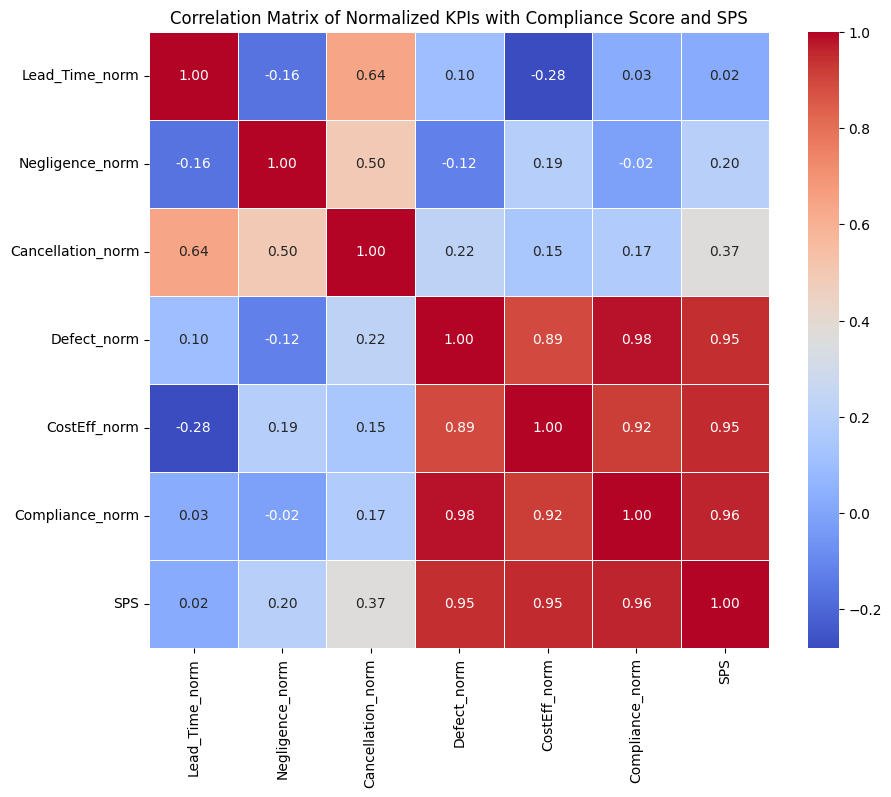

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant normalized KPI columns from the 'kpis' DataFrame
correlation_data = kpis[['Lead_Time_norm', 'Negligence_norm', 'Cancellation_norm', 'Defect_norm', 'CostEff_norm', 'Compliance_norm', 'SPS']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Normalized KPIs with Compliance Score and SPS')
plt.show()

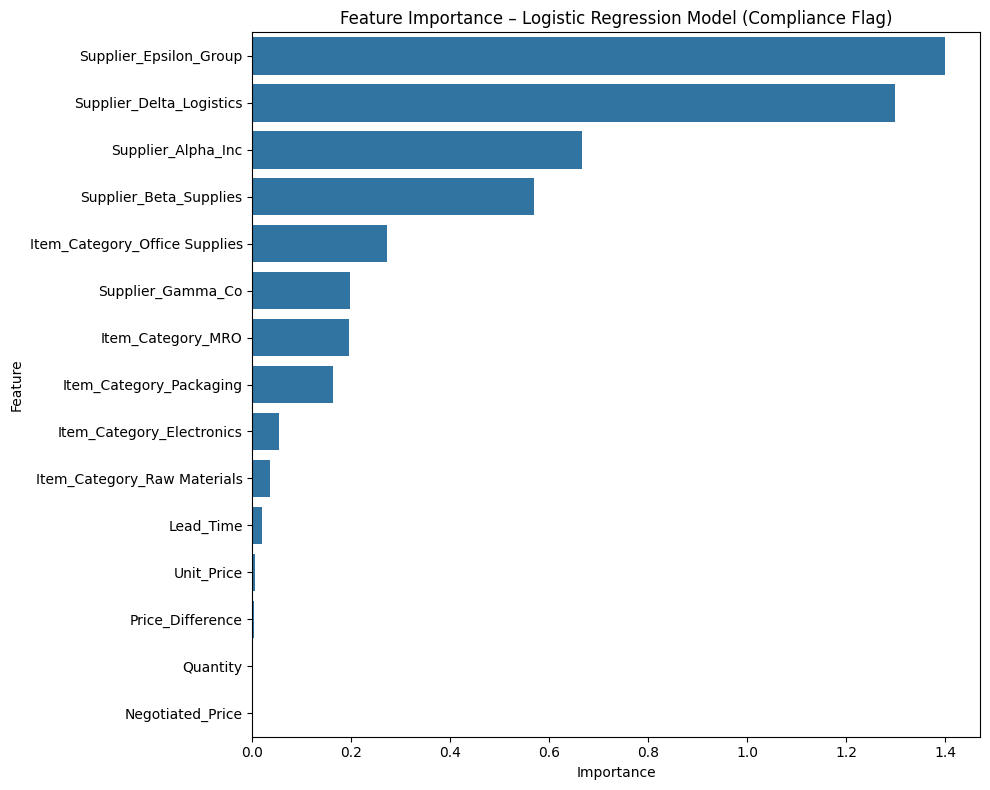

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract the LogisticRegression estimator from the pipeline
logistic_reg_estimator = clf_model.named_steps['classifier']

# Get feature coefficients. For binary classification, coef_ is a 1D array.
# We take the absolute value as importance for interpretation.
importances = abs(logistic_reg_estimator.coef_[0])

# Get feature names after preprocessing, similar to the regression model
categorical_features = clf_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(['Supplier', 'Item_Category'])
numeric_features = ['Quantity', 'Unit_Price', 'Negotiated_Price', 'Price_Difference', 'Lead_Time']
all_features = list(categorical_features) + numeric_features

# Create DataFrame for feature importance
feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_df, x='Importance', y='Feature')
plt.title("Feature Importance – Logistic Regression Model (Compliance Flag)")
plt.tight_layout()
plt.show()

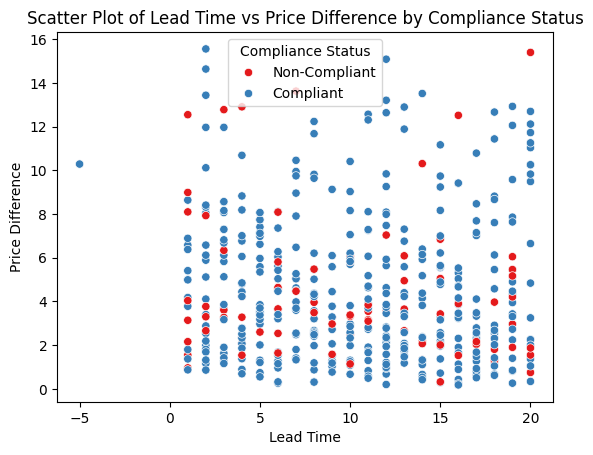

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a mapping for legend labels
label_map = {0: "Non-Compliant", 1: "Compliant"}

sns.scatterplot(
    data=model_df,
    x='Lead_Time',
    y='Price_Difference',
    hue='Compliance_Flag',
    palette='Set1',
    legend='full'
)

# Fix the legend labels
handles, labels = plt.gca().get_legend_handles_labels()

# Determine the correct start index for labels to map
# If the first label is not a number (i.e., it's the hue title), skip it
start_index = 0
if len(labels) > 0 and not (labels[0].isdigit() or (labels[0].startswith('-') and labels[0][1:].isdigit())):
    start_index = 1

# Map the numerical labels to their descriptive names
mapped_labels = [label_map[int(l)] for l in labels[start_index:] if l.isdigit() or (l.startswith('-') and l[1:].isdigit())]

plt.legend(handles[start_index:], mapped_labels, title="Compliance Status")

plt.title("Scatter Plot of Lead Time vs Price Difference by Compliance Status")
plt.xlabel("Lead Time")
plt.ylabel("Price Difference")
plt.show()

**PREDICTIVE ANALYTICS - PREDICT DEFECT RATE USING RANDOM FOREST REGRESSION**

### Data Preparation for Regression Model

For the regression model to predict `Defect_Rate`, `model_df` is created for the classification task. This DataFrame already contains merged `Lead_Time` and other relevant features. A copy is created, `model_df_reg`, to calculate the `Defect_Rate` from `Defective_Units` and `Quantity`. Also rows with `NaN` values are dropped as these might result from these calculations to ensure a clean dataset for training.

In [32]:
import pandas as pd

# Create a copy from model_df for regression task
model_df_reg = model_df.copy()

# Calculate Defect_Rate
# Handle potential division by zero by setting Defect_Rate to 0 where Quantity is 0 or NaN
model_df_reg['Defect_Rate'] = model_df_reg.apply(
    lambda row: row['Defective_Units'] / row['Quantity'] if row['Quantity'] > 0 else 0,
    axis=1
)

# Drop rows where 'Defect_Rate' or any of the features are NaN (e.g., if Defective_Units was NaN)
numeric_cols_for_X2 = ['Quantity', 'Unit_Price', 'Negotiated_Price', 'Price_Difference', 'Lead_Time']
model_df_reg.dropna(subset=['Defect_Rate'] + numeric_cols_for_X2, inplace=True)

print(f"Shape of the prepared dataframe for regression modeling: {model_df_reg.shape}")
display(model_df_reg.head())
display(model_df_reg.info())

Shape of the prepared dataframe for regression modeling: (402, 16)


,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Price_Difference,PCS,Lead_Time,Compliance_Flag,Defect_Rate
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,1.98,1,10.0,1,0.155732
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes,3.25,3,20.0,1,0.045055
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes,4.33,2,19.0,1,0.083333
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No,3.54,5,12.0,0,0.144915
5,PO-00006,Epsilon_Group,2022-08-17,2022-08-29,MRO,Delivered,1145,69.21,63.57,39.0,Yes,5.64,3,12.0,1,0.034061


<class 'pandas.core.frame.DataFrame'>
Index: 402 entries, 1 to 776
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             402 non-null    object 
 1   Supplier          402 non-null    object 
 2   Order_Date        402 non-null    object 
 3   Delivery_Date     402 non-null    object 
 4   Item_Category     402 non-null    object 
 5   Order_Status      402 non-null    object 
 6   Quantity          402 non-null    int64  
 7   Unit_Price        402 non-null    float64
 8   Negotiated_Price  402 non-null    float64
 9   Defective_Units   402 non-null    float64
 10  Compliance        402 non-null    object 
 11  Price_Difference  402 non-null    float64
 12  PCS               402 non-null    int64  
 13  Lead_Time         402 non-null    float64
 14  Compliance_Flag   402 non-null    int64  
 15  Defect_Rate       402 non-null    float64
dtypes: float64(6), int64(3), object(7)
memory usage: 

None

### Regression Model Training and Evaluation

Now that the data is prepared in `model_df_reg`, I will proceed with your provided code to train a RandomForestRegressor to predict the `Defect_Rate`. The model will use one-hot encoding for categorical features (`Supplier`, `Item_Category`) and pass through numeric features (`Quantity`, `Unit_Price`, `Negotiated_Price`, `Price_Difference`, `Lead_Time`). After training, the model's performance will be evaluated using Mean Absolute Error (MAE) and R2 Score.

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Regression Target
y2 = model_df_reg['Defect_Rate']

# 2. Features
X2 = model_df_reg[['Quantity', 'Unit_Price', 'Negotiated_Price', 'Price_Difference',
         'Lead_Time', 'Supplier', 'Item_Category']]

# 3. Preprocessing (same as before)
preprocessor2 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Supplier', 'Item_Category']),
        ('num', 'passthrough', ['Quantity','Unit_Price','Negotiated_Price','Price_Difference','Lead_Time'])
    ]
)

# 4. Regression pipeline
reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

# 5. Train/test split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# 6. Train
reg_model.fit(X2_train, y2_train)

# 7. Predict
y2_pred = reg_model.predict(X2_test)

# 8. Evaluation
print("MAE:", mean_absolute_error(y2_test, y2_pred))
print("R2 Score:", r2_score(y2_test, y2_pred))

MAE: 0.009594543457727277
R2 Score: 0.917925836909495


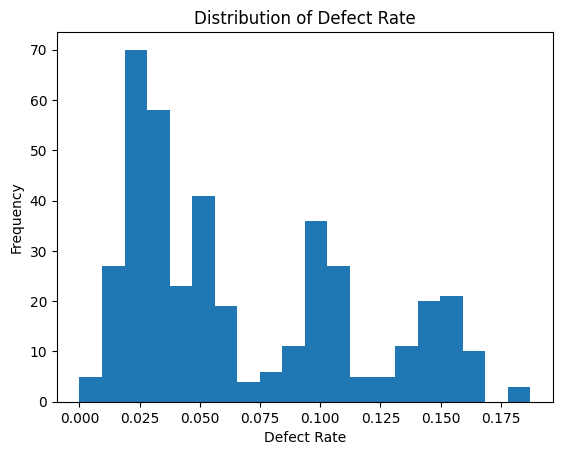

In [34]:
plt.hist(model_df_reg['Defect_Rate'], bins=20)
plt.title("Distribution of Defect Rate")
plt.xlabel("Defect Rate")
plt.ylabel("Frequency")
plt.show()

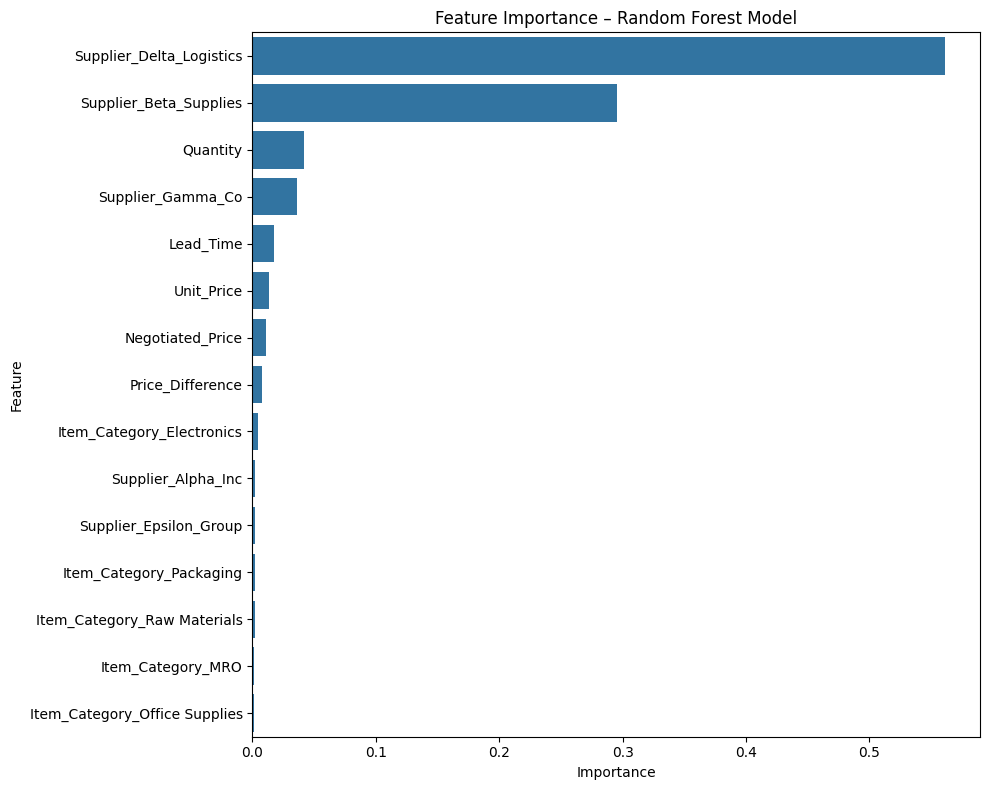

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract the RandomForestRegressor from the pipeline
rf_reg_estimator = reg_model.named_steps['regressor']

# Get feature importances
importances = rf_reg_estimator.feature_importances_

# Get feature names after preprocessing
categorical_features = reg_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(['Supplier', 'Item_Category'])
numeric_features = ['Quantity', 'Unit_Price', 'Negotiated_Price', 'Price_Difference', 'Lead_Time']
all_features = list(categorical_features) + numeric_features

# Create DataFrame for feature importance
feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_df, x='Importance', y='Feature')
plt.title("Feature Importance – Random Forest Model")
plt.tight_layout()
plt.show()